# Julia Sets & Complex Iteration

## Complex Quadratic Dynamics

Consider the iteration of the quadratic map:
$$f_c(z) = z^2 + c, \quad z, c \in \mathbb{C}$$

For a fixed parameter $c$, the orbit of a starting point $z_0$ is:
$$z_0,\quad z_1 = f_c(z_0),\quad z_2 = f_c(z_1),\quad \ldots$$

The orbit either **escapes to infinity** or remains **bounded**.

## The Julia Set

The **Julia set** $J_c$ for parameter $c$ is the boundary between the basins of attraction:
$$J_c = \partial \{z : f_c^n(z) \to \infty\}$$

Equivalently, $J_c$ is the closure of the set of repelling periodic points of $f_c$.

## The Mandelbrot Set

The **Mandelbrot set** $\mathcal{M}$ is the set of parameters $c$ for which the orbit of $z = 0$ is bounded:
$$c \in \mathcal{M} \iff \sup_n |f_c^n(0)| < \infty$$

**Key theorem**: $J_c$ is connected iff $c \in \mathcal{M}$; otherwise $J_c$ is a Cantor set ("dust").

## Escape Time Algorithm

For visualization, we color each point $z$ by the number of iterations before $|z^n| > 2$ (the escape radius). The **smooth iteration count** uses fractional coloring:
$$N_{\text{smooth}}(z_0) = n + 1 - \log_2 \log_2 |z_n|$$

to eliminate the discrete band artifacts.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

### Escape time computation

We vectorize the iteration over all grid points simultaneously. The escape test $|z| \geq 2$ is performed at every step; escaped points are frozen at their escape time. The **smooth coloring** function removes the harsh band transitions by computing a fractional escape count.

In [2]:
def julia_escape(c, center=0+0j, radius=1.8, n=400, n_iter=200, smooth=True):
    """
    Compute escape-time map for f_c(z) = z^2 + c.
    Returns array of shape (n, n) with escape counts (float if smooth=True).
    """
    t = np.linspace(-radius, radius, n)
    tx = center.real + t
    ty = center.imag + t
    Y, X = np.meshgrid(ty, tx)
    Z = X + 1j * Y
    Z0 = Z.copy()

    escape = np.full(Z.shape, n_iter, dtype=float)
    escaped = np.zeros(Z.shape, dtype=bool)
    r_max = 2.0

    for i in range(1, n_iter + 1):
        Z = Z**2 + c
        mask = (~escaped) & (np.abs(Z) >= r_max)
        escape[mask] = i
        escaped |= mask
        Z[escaped] = r_max  # freeze escaped points

    if smooth:
        # Smooth coloring: avoid log(0)
        log2abs = np.log2(np.maximum(np.log2(np.abs(Z0) + 1e-10 * (escape < n_iter)), 1e-10))
        escape = escape + 1 - log2abs
        escape[escape >= n_iter] = n_iter

    return escape

### Gallery of Julia sets

Different values of $c$ produce dramatically different Julia sets:
- $c = 0$: unit circle (trivial)
- $c = -1$: "San Marco" fractal (cauliflower shape)
- $c = -0.4 + 0.6i$: connected dendrite-like set
- $c = -0.624 + 0.435i$: elaborate connected fractal
- $c = -0.7269 + 0.1889i$: "Douady rabbit"
- $c = -0.835 - 0.2321i$: cantor-like dust

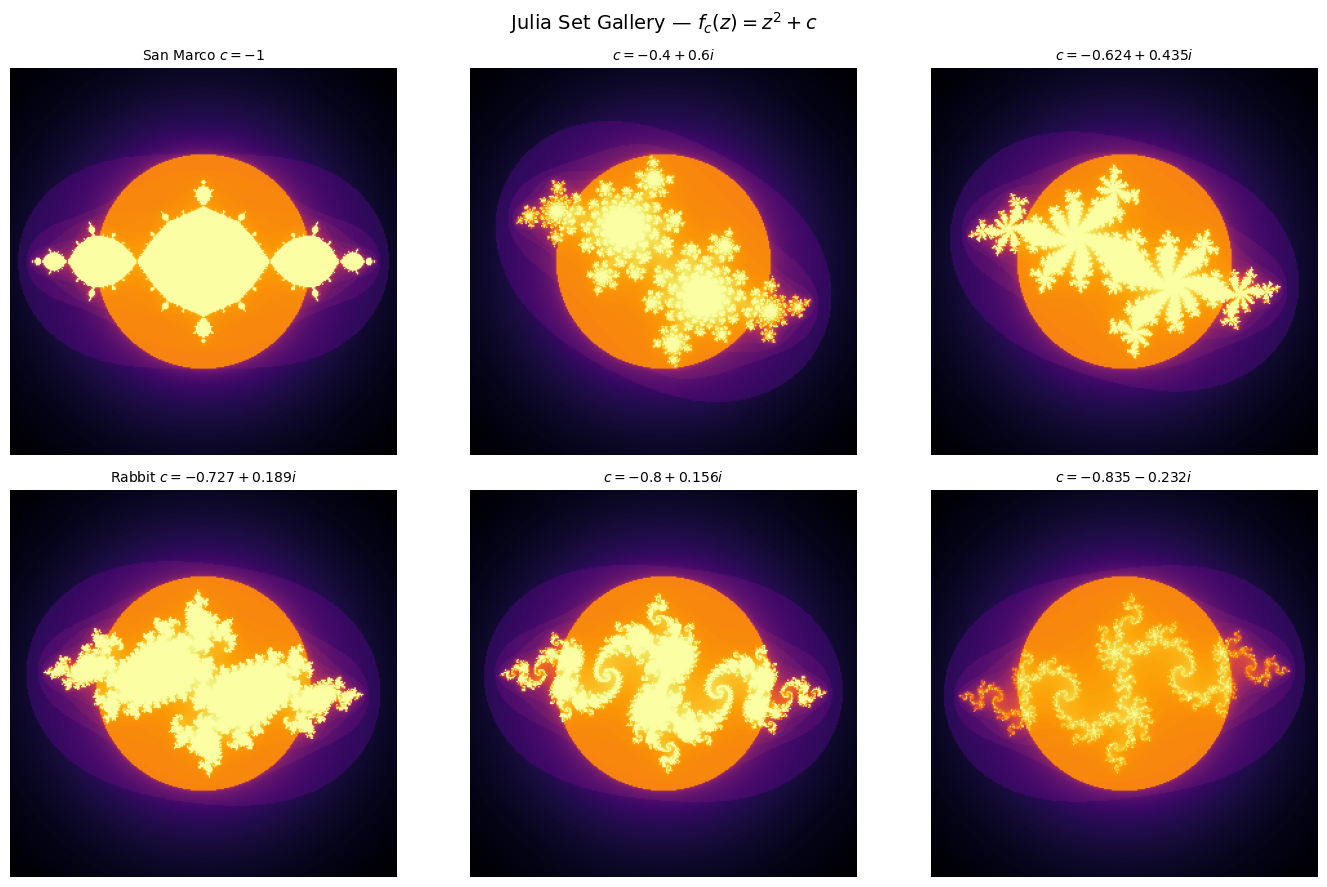

In [3]:
c_values = [
    (-1.0 + 0j,     'San Marco $c=-1$'),
    (-0.4 + 0.6j,   '$c=-0.4+0.6i$'),
    (-0.624+0.435j, '$c=-0.624+0.435i$'),
    (-0.7269+0.1889j, 'Rabbit $c=-0.727+0.189i$'),
    (-0.8+0.156j,   '$c=-0.8+0.156i$'),
    (-0.835-0.2321j,'$c=-0.835-0.232i$'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (c, label) in zip(axes.ravel(), c_values):
    Q = julia_escape(c, n=300, n_iter=100, smooth=True)
    ax.imshow(np.log1p(Q).T, cmap='inferno', origin='lower', aspect='equal')
    ax.set_title(label, fontsize=10); ax.axis('off')

plt.suptitle('Julia Set Gallery — $f_c(z) = z^2 + c$', fontsize=14)
plt.tight_layout(); plt.savefig('julia_gallery.png', dpi=100, bbox_inches='tight'); plt.show()

### Self-similar zoom

Julia sets are **self-similar** fractals: zooming in reveals the same intricate structure at every scale. We show a sequence of zooms centered on an interesting region.

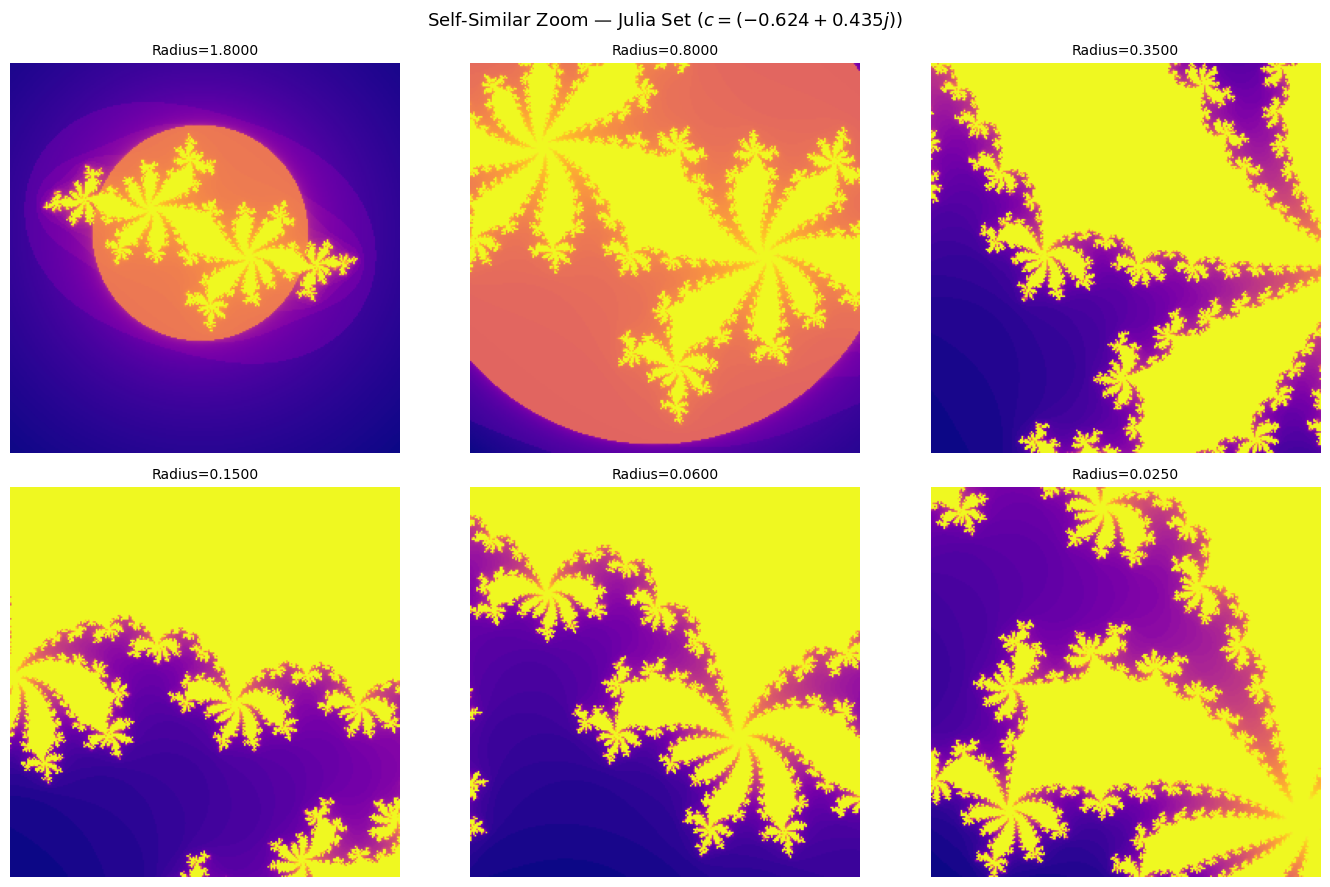

In [4]:
c_zoom = -0.624 + 0.435j
z_target = 0.044 - 0.233j  # interesting region

radii = [1.8, 0.8, 0.35, 0.15, 0.06, 0.025]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, r in zip(axes.ravel(), radii):
    Q = julia_escape(c_zoom, center=z_target, radius=r, n=250, n_iter=150)
    ax.imshow(np.log1p(Q).T, cmap='plasma', origin='lower', aspect='equal')
    ax.set_title(f'Radius={r:.4f}', fontsize=10); ax.axis('off')

plt.suptitle(f'Self-Similar Zoom — Julia Set ($c={c_zoom}$)', fontsize=13)
plt.tight_layout(); plt.savefig('julia_zoom.png', dpi=100, bbox_inches='tight'); plt.show()

### Connection to the Mandelbrot set

We visualize the Mandelbrot set (escape-time of the critical orbit $z_0=0$) alongside four Julia sets at representative parameter values. The qualitative nature of the Julia set (connected vs. disconnected) is determined by whether $c$ is inside or outside $\mathcal{M}$.

/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_30689/2035114233.py:44: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout(); plt.savefig('julia_mandelbrot.png', dpi=100, bbox_inches='tight'); plt.show()


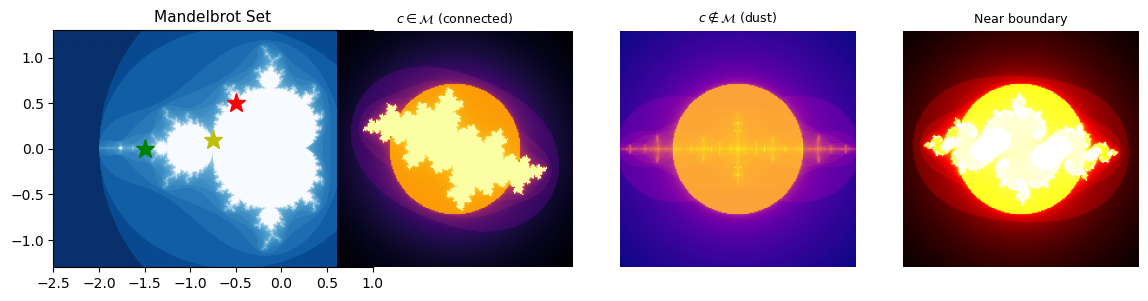

In [5]:
def mandelbrot_escape(n=300, n_iter=100, xlim=(-2.5,1.0), ylim=(-1.3,1.3)):
    tx = np.linspace(*xlim, n)
    ty = np.linspace(*ylim, n)
    Y, X = np.meshgrid(ty, tx)
    C = X + 1j * Y
    Z = np.zeros_like(C)
    escape = np.full(C.shape, n_iter, dtype=float)
    escaped = np.zeros(C.shape, dtype=bool)
    for i in range(1, n_iter+1):
        Z = Z**2 + C
        mask = (~escaped) & (np.abs(Z) >= 2)
        escape[mask] = i
        escaped |= mask
        Z[escaped] = 2.0
    return escape

M = mandelbrot_escape(n=300, n_iter=100)

# Julia sets at 4 representative c values
c_inside = -0.5 + 0.5j     # inside M -> connected J
c_outside = -1.5 + 0j      # outside M -> disconnected J
c_boundary = -0.75225 + 0.1j  # near boundary

fig = plt.figure(figsize=(14, 6))
# Mandelbrot
ax_m = fig.add_subplot(1, 3, 1)
ax_m.imshow(np.log1p(M).T, cmap='Blues_r', origin='lower',
             extent=[-2.5,1.0,-1.3,1.3], aspect='equal')
for c_pt, col in [(c_inside,'r'), (c_outside,'g'), (c_boundary,'y')]:
    ax_m.plot(c_pt.real, c_pt.imag, f'{col}*', ms=14)
ax_m.set_title('Mandelbrot Set', fontsize=11)

for i, (c_pt, label, cmap_j) in enumerate([
    (c_inside,   f'$c \\in \\mathcal{{M}}$ (connected)', 'inferno'),
    (c_outside,  f'$c \\notin \\mathcal{{M}}$ (dust)', 'plasma'),
    (c_boundary, 'Near boundary', 'hot')
]):
    ax_j = fig.add_subplot(1, 4, i+2) if i < 3 else None
    if ax_j:
        Q_j = julia_escape(c_pt, n=200, n_iter=80)
        ax_j.imshow(np.log1p(Q_j).T, cmap=cmap_j, origin='lower', aspect='equal')
        ax_j.set_title(label, fontsize=9); ax_j.axis('off')

plt.tight_layout(); plt.savefig('julia_mandelbrot.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: explore the Julia set parameter space

In [ ]:
def show_julia(c_re=-0.624, c_im=0.435, n_iter=100,
               colormap='inferno'):
    c_i = c_re + 1j * c_im
    Q = julia_escape(c_i, n=300, n_iter=n_iter, smooth=True)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(np.log1p(Q).T, cmap=colormap, origin='lower', aspect='equal')
    ax.set_title(f'Julia set — $c = {c_re:.3f} + {c_im:.3f}i$')
    ax.axis('off'); plt.tight_layout(); plt.show()

interact(show_julia,
         c_re=FloatSlider(min=-2, max=0.5, step=0.01, value=-0.624, description='Re(c)'),
         c_im=FloatSlider(min=-1.5, max=1.5, step=0.01, value=0.435, description='Im(c)'),
         n_iter=IntSlider(min=30, max=300, step=10, value=100),
         colormap=Dropdown(options=['inferno','plasma','hot','Blues','viridis'], value='inferno'));

### Snippet

In [6]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(2, 3, figsize=(12, 8))
    cmaps = ['inferno','plasma','hot','viridis','magma','cividis']
    for ax, (c, label), cmap_j in zip(axes.ravel(), c_values, cmaps):
        Q = julia_escape(c, n=250, n_iter=80, smooth=True)
        ax.imshow(np.log1p(Q).T, cmap=cmap_j, origin='lower', aspect='equal')
        ax.set_title(label, fontsize=9); ax.axis('off')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- Julia sets are the boundaries of bounded orbits for the quadratic family $f_c(z) = z^2 + c$.
- They are **connected** iff $c \in \mathcal{M}$ (Mandelbrot set), and Cantor dust otherwise.
- The **escape time algorithm** provides an efficient approximation, with smooth coloring eliminating banding artifacts.
- Julia sets exhibit **self-similarity** at every scale — the hallmark of fractals.

## Bibliography

- B. Mandelbrot, *The Fractal Geometry of Nature*, W. H. Freeman, 1982.
- J. Milnor, *Dynamics in One Complex Variable*, Princeton UP, 2006.
- A. Douady & J. Hubbard, *Étude dynamique des polynômes complexes*, Publ. Math. Orsay, 1984.